In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [3]:
df = pd.read_csv("../data/processed/avis.csv")

In [9]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,year,month,clean_text,lemmatized,text_length,word_count
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,2021-10-06,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN,2021,10,la personne au téléphone était clair et sympat...,téléphone clair sympathique bien expliquer rec...,167,26
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,2021-07-09,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN,2021,7,satisfait\n\nréactivité simplicité prix attrac...,satisfaire \n\n réactivité simplicité prix att...,163,22
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,2020-10-15,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN,2020,10,assureur à fuir n assure pas ses responsabilit...,assureur fuir n assurer responsabilité agent d...,213,36
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,2020-03-03,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN,2020,3,voilà 3 mois que la gmf me fait attendre pour ...,3 mois gmf attendre dégât eau jer contrat,124,23
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,2021-08-28,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN,2021,8,je suis bien avec cet assuranceelle est pratiq...,bien assuranceelle pratique moin cherj trouve ...,170,28


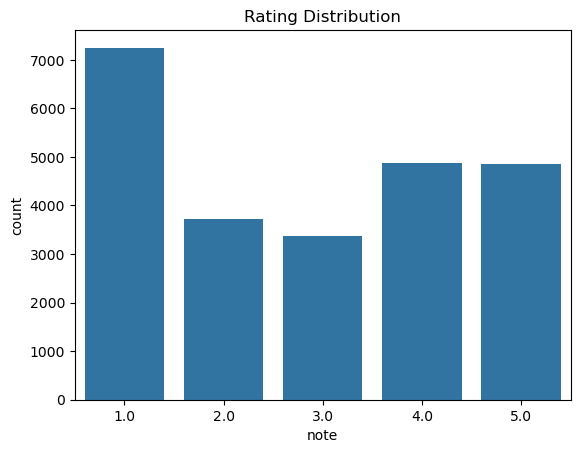

In [10]:
sns.countplot(x='note', data=df)
plt.title("Rating Distribution")
plt.show()

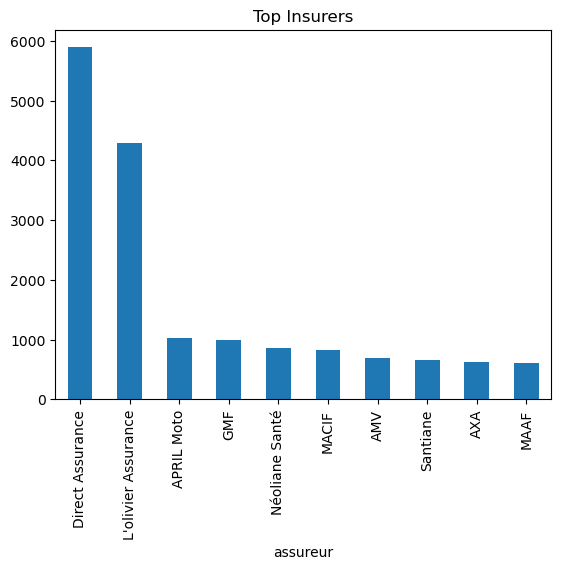

In [11]:
df['assureur'].value_counts().head(10).plot(kind='bar')
plt.title("Top Insurers")
plt.show()

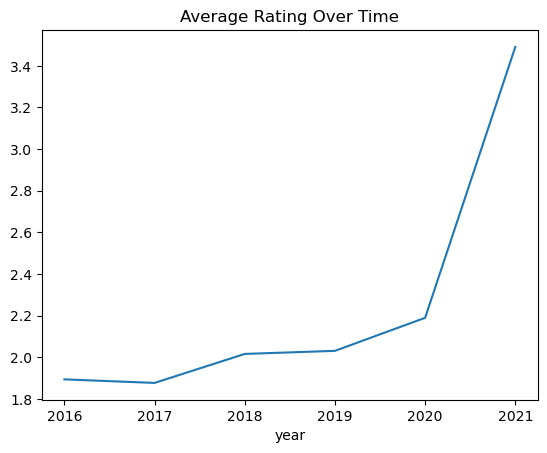

In [12]:
df.groupby('year')['note'].mean().plot()
plt.title("Average Rating Over Time")
plt.show()

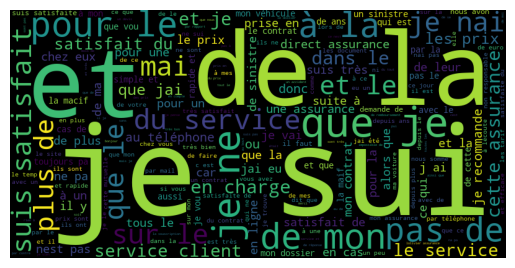

In [13]:
text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [14]:
vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df['clean_text'])

ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

ngram_df = pd.DataFrame({'ngram': ngrams, 'count': counts})
ngram_df.sort_values(by='count', ascending=False)

,ngram,count
10,je suis,8104
2,de la,5157
16,que je,3549
8,je ne,2930
3,de mon,2528
13,pas de,2205
4,du service,2133
19,suis satisfait,2054
7,je nai,1998
14,plus de,1835


In [15]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

In [16]:
for rating in sorted(df['note'].unique()):
    subset = df[df['note'] == rating]
    text = " ".join(subset['clean_text'])
    print(f"\nRating {rating} top words:")
    
    vec = CountVectorizer(max_features=10)
    X = vec.fit_transform([text])
    print(vec.get_feature_names_out())


Rating 1.0 top words:
['de' 'en' 'et' 'je' 'la' 'le' 'pas' 'pour' 'que' 'un']

Rating 2.0 top words:
['de' 'en' 'et' 'je' 'la' 'le' 'pas' 'pour' 'que' 'un']

Rating 3.0 top words:
['de' 'en' 'et' 'je' 'la' 'le' 'les' 'pas' 'pour' 'que']

Rating 4.0 top words:
['de' 'en' 'et' 'je' 'la' 'le' 'les' 'pour' 'suis' 'très']

Rating 5.0 top words:
['de' 'et' 'je' 'la' 'le' 'les' 'pour' 'prix' 'suis' 'très']
